# UPSCALeDEV CAISO AS Attenuation-Factor Postprocessing

This source notebook converts the official CAISO quarterly Energy Storage Enhancements attenuation-factor workbooks into the hourly RU/RD alpha lookup used by the sensitivity model. These factors are official SOC attenuation factors, not realized 15-minute AGC deployment traces.

In [1]:
from pathlib import Path
import hashlib
import re
import xml.etree.ElementTree as ET
from zipfile import ZipFile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
DATA_DIR = ROOT / '2025Data/AS_Call_Rates'
RAW_FILES = {
    '2025Q4': DATA_DIR / 'energy-storage-enhancements-attenuation-factors-q4-2025.xlsx',
    '2025Q1': DATA_DIR / 'energy-storage-enhancements-attenuation-factors-q1-2025.xlsx',
    '2025Q2': DATA_DIR / 'energy-storage-enhancements-attenuation-factors-q2-2025.xlsx',
    '2025Q3': DATA_DIR / 'energy-storage-enhancements-attenuation-factors-q3-2025.xlsx',
}
SOURCE_URLS = {
    '2025Q4': 'https://www.caiso.com/documents/energy-storage-enhancements-attenuation-factors-q4-2025.xlsx',
    '2025Q1': 'https://www.caiso.com/documents/energy-storage-enhancements-attenuation-factors-q1-2025.xlsx',
    '2025Q2': 'https://www.caiso.com/documents/energy-storage-enhancements-attenuation-factors-q2-2025.xlsx',
    '2025Q3': 'https://www.caiso.com/documents/energy-storage-enhancements-attenuation-factors-q3-2025.xlsx',
}
RAW_FILES = dict(sorted(RAW_FILES.items()))
OUTPUT = DATA_DIR / 'caiso_regulation_attenuation_hourly_2025.csv'
SUMMARY = DATA_DIR / 'caiso_regulation_attenuation_hourly_2025_QC_summary.csv'
PLOT = DATA_DIR / 'caiso_regulation_attenuation_hourly_2025.png'

def sha256(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

def read_simple_official_xlsx(path):
    """Read the first worksheet using only the Python standard library."""
    ns = {'x': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}
    with ZipFile(path) as archive:
        shared = []
        if 'xl/sharedStrings.xml' in archive.namelist():
            root = ET.fromstring(archive.read('xl/sharedStrings.xml'))
            for item in root.findall('x:si', ns):
                shared.append(''.join(node.text or '' for node in item.iter() if node.tag.endswith('}t')))
        sheet = ET.fromstring(archive.read('xl/worksheets/sheet1.xml'))
    rows = []
    for row in sheet.findall('.//x:sheetData/x:row', ns):
        values = {}
        for cell in row.findall('x:c', ns):
            ref = cell.attrib.get('r', '')
            letters = re.match(r'[A-Z]+', ref).group(0)
            col = 0
            for letter in letters:
                col = col * 26 + ord(letter) - 64
            value_node = cell.find('x:v', ns)
            value = None if value_node is None else value_node.text
            if value is not None and cell.attrib.get('t') == 's':
                value = shared[int(value)]
            elif value is not None:
                value = float(value)
                if value.is_integer():
                    value = int(value)
            values[col] = value
        rows.append([values.get(i) for i in range(1, max(values) + 1)])
    return pd.DataFrame(rows[1:], columns=rows[0])

In [2]:
frames = []
summary_rows = []
for quarter, path in RAW_FILES.items():
    if not path.exists():
        import requests
        from io import BytesIO
        response = requests.get(SOURCE_URLS[quarter], timeout=60)
        response.raise_for_status()
        with ZipFile(BytesIO(response.content)) as archive:
            assert 'xl/workbook.xml' in archive.namelist()
        path.write_bytes(response.content)
    raw = read_simple_official_xlsx(path)
    required = {'TRADE_HR', 'Reg_Up', 'Reg_Down'}
    if not required.issubset(raw.columns):
        raise KeyError(f'{path.name} missing {sorted(required - set(raw.columns))}')
    clean = raw[['TRADE_HR', 'Reg_Up', 'Reg_Down']].rename(columns={
        'TRADE_HR': 'trade_hour', 'Reg_Up': 'alpha_RU', 'Reg_Down': 'alpha_RD'
    }).copy()
    clean['trade_hour'] = pd.to_numeric(clean['trade_hour'], errors='raise').astype(int)
    clean['alpha_RU'] = pd.to_numeric(clean['alpha_RU'], errors='raise')
    clean['alpha_RD'] = pd.to_numeric(clean['alpha_RD'], errors='raise')
    if len(clean) != 24 or set(clean['trade_hour']) != set(range(1, 25)):
        raise ValueError(f'{quarter} must contain each trade hour 1..24 exactly once')
    if clean['trade_hour'].duplicated().any() or not clean[['alpha_RU', 'alpha_RD']].apply(lambda s: s.between(0, 1).all()).all():
        raise ValueError(f'Invalid attenuation values in {quarter}')
    clean.insert(0, 'quarter', quarter)
    clean['source_url'] = SOURCE_URLS[quarter]
    clean['source_note'] = 'CAISO hourly SOC attenuation factor; not realized AGC deployment'
    frames.append(clean)
    summary_rows.append({
        'quarter': quarter, 'raw_file': path.name, 'raw_sha256': sha256(path),
        'rows': len(clean), 'trade_hour_min': int(clean['trade_hour'].min()),
        'trade_hour_max': int(clean['trade_hour'].max()),
        'alpha_RU_min': float(clean['alpha_RU'].min()), 'alpha_RU_mean': float(clean['alpha_RU'].mean()), 'alpha_RU_max': float(clean['alpha_RU'].max()),
        'alpha_RD_min': float(clean['alpha_RD'].min()), 'alpha_RD_mean': float(clean['alpha_RD'].mean()), 'alpha_RD_max': float(clean['alpha_RD'].max()),
        'source_url': SOURCE_URLS[quarter],
    })

attenuation = pd.concat(frames, ignore_index=True).sort_values(['quarter', 'trade_hour']).reset_index(drop=True)
attenuation.to_csv(OUTPUT, index=False, float_format='%.6f')
summary = pd.DataFrame(summary_rows)
summary.to_csv(SUMMARY, index=False)
display(attenuation)
display(summary)

,quarter,trade_hour,alpha_RU,alpha_RD,source_url,source_note
0,2025Q2,1,0.127,0.303,https://www.caiso.com/documents/energy-storage...,CAISO hourly SOC attenuation factor; not reali...
1,2025Q2,2,0.054,0.287,https://www.caiso.com/documents/energy-storage...,CAISO hourly SOC attenuation factor; not reali...
2,2025Q2,3,0.042,0.271,https://www.caiso.com/documents/energy-storage...,CAISO hourly SOC attenuation factor; not reali...
3,2025Q2,4,0.041,0.262,https://www.caiso.com/documents/energy-storage...,CAISO hourly SOC attenuation factor; not reali...
4,2025Q2,5,0.041,0.251,https://www.caiso.com/documents/energy-storage...,CAISO hourly SOC attenuation factor; not reali...
5,2025Q2,6,0.079,0.243,https://www.caiso.com/documents/energy-storage...,CAISO hourly SOC attenuation factor; not reali...
6,2025Q2,7,0.143,0.309,https://www.caiso.com/documents/energy-storage...,CAISO hourly SOC attenuation factor; not reali...
7,2025Q2,8,0.167,0.357,https://www.caiso.com/documents/energy-storage...,CAISO hourly SOC attenuation factor; not reali...
8,2025Q2,9,0.086,0.346,https://www.caiso.com/documents/energy-storage...,CAISO hourly SOC attenuation factor; not reali...
9,2025Q2,10,0.056,0.282,https://www.caiso.com/documents/energy-storage...,CAISO hourly SOC attenuation factor; not reali...


,quarter,raw_file,raw_sha256,rows,trade_hour_min,trade_hour_max,alpha_RU_min,alpha_RU_mean,alpha_RU_max,alpha_RD_min,alpha_RD_mean,alpha_RD_max,source_url
0,2025Q2,energy-storage-enhancements-attenuation-factor...,0ee04187225c815c08853175d075d91274246a8c188bed...,24,1,24,0.041,0.088583,0.204,0.243,0.326917,0.605,https://www.caiso.com/documents/energy-storage...
1,2025Q3,energy-storage-enhancements-attenuation-factor...,e678fda0135be1e4668dba24bf00f412bed27c0b23ec1a...,24,1,24,0.048,0.104458,0.216,0.227,0.325833,0.558,https://www.caiso.com/documents/energy-storage...


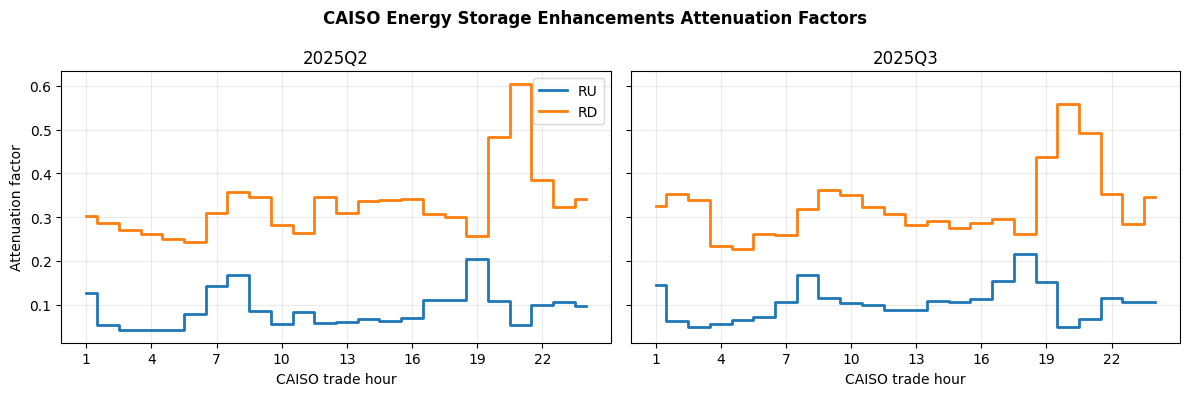

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
axes = axes.ravel()
for ax, quarter in zip(axes, RAW_FILES):
    q = attenuation[attenuation['quarter'] == quarter]
    ax.step(q['trade_hour'], q['alpha_RU'], where='mid', label='RU', linewidth=2)
    ax.step(q['trade_hour'], q['alpha_RD'], where='mid', label='RD', linewidth=2)
    ax.set_title(quarter)
    ax.set_xlabel('CAISO trade hour')
    ax.set_xticks(range(1, 25, 3))
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Attenuation factor')
axes[0].legend()
fig.suptitle('CAISO Energy Storage Enhancements Attenuation Factors', fontweight='bold')
fig.tight_layout()
fig.savefig(PLOT, dpi=300, bbox_inches='tight')
plt.show()

In [4]:
assert len(attenuation) == 96
assert attenuation.groupby('quarter')['trade_hour'].nunique().eq(24).all()
assert attenuation[['alpha_RU', 'alpha_RD']].notna().all().all()
assert attenuation[['alpha_RU', 'alpha_RD']].apply(lambda s: s.between(0, 1).all()).all()
round_trip = pd.read_csv(OUTPUT)
assert np.max(np.abs(round_trip[['alpha_RU', 'alpha_RD']].to_numpy() - attenuation[['alpha_RU', 'alpha_RD']].to_numpy())) < 1e-12
print('AS attenuation postprocessing validation: PASS')
print('Output SHA256:', sha256(OUTPUT))

AS attenuation postprocessing validation: PASS
Output SHA256: 52917c3124d4f23191a61ee52ae1d800b5356a380ae8d8e2364add75ae0e05db
